# Insurance Expenditure Analysis in Greece

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Data Loading and Initial Inspection

In [2]:
df = pd.read_excel("insurance_expenditure_greece_2008_2020.xlsx")
df.head()

,year,category_type,segment,insurance_type,insurance_expenditure
0,2008,area,Rural,Life,9.02
1,2008,area,Rural,Home,2.23
2,2008,area,Rural,Health,9.00
3,2008,area,Rural,Motor & Travel,34.53
4,2014,area,Rural,Life,3.75


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   320 non-null    int64  
 1   category_type          320 non-null    object 
 2   segment                320 non-null    object 
 3   insurance_type         320 non-null    object 
 4   insurance_expenditure  320 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 12.6+ KB


In [4]:
df.isnull().sum()

year                     0
category_type            0
segment                  0
insurance_type           0
insurance_expenditure    0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nYears:")
print(df["year"].unique())

print("\nInsurance types:")
print(df["insurance_type"].unique())

print("\nSegmentation categories:")
print(df["category_type"].unique())

Rows: 320
Columns: 5

Years:
[2008 2014 2020]

Insurance types:
['Life' 'Home' 'Health' 'Motor & Travel']

Segmentation categories:
['area' 'region' 'spending_class' 'occupation']


## Overall Insurance Spending Trend

In [7]:
avg_by_year = df.groupby("year")["insurance_expenditure"].mean().reset_index()
avg_by_year

,year,insurance_expenditure
0,2008,12.541667
1,2014,9.454516
2,2020,8.412097


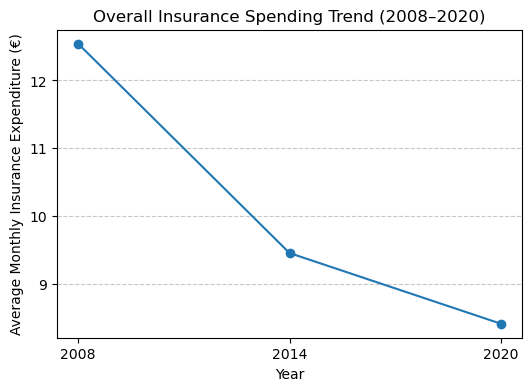

In [8]:
plt.figure(figsize=(6,4))
plt.plot(avg_by_year["year"], avg_by_year["insurance_expenditure"], marker="o")

plt.title("Overall Insurance Spending Trend (2008–2020)")
plt.xlabel("Year")
plt.ylabel("Average Monthly Insurance Expenditure (€)")
plt.xticks(avg_by_year["year"])
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

## Insurance Spending Trends by Product Type

In [9]:
avg_by_type_year = df.groupby(["year", "insurance_type"])["insurance_expenditure"].mean().reset_index()
avg_by_type_year

,year,insurance_type,insurance_expenditure
0,2008,Health,8.052222
1,2008,Home,1.992778
2,2008,Life,8.128889
3,2008,Motor & Travel,31.992778
4,2014,Health,5.685806
5,2014,Home,1.431613
6,2014,Life,3.542903
7,2014,Motor & Travel,27.157742
8,2020,Health,8.433548
9,2020,Home,0.982903


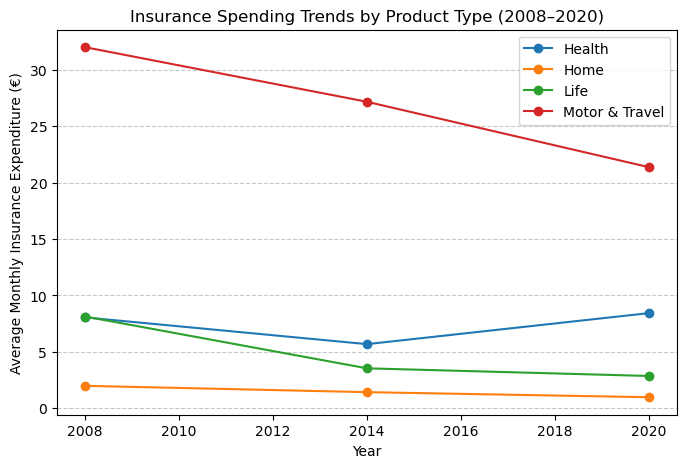

In [10]:
plt.figure(figsize=(8,5))

for insurance in avg_by_type_year["insurance_type"].unique():
    subset = avg_by_type_year[avg_by_type_year["insurance_type"] == insurance]
    plt.plot(subset["year"], subset["insurance_expenditure"], marker="o", label=insurance)

plt.title("Insurance Spending Trends by Product Type (2008–2020)")
plt.xlabel("Year")
plt.ylabel("Average Monthly Insurance Expenditure (€)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

## Urban vs Rural Insurance Spending

In [11]:
area_df = df[df["category_type"] == "area"]
area_df.head()


,year,category_type,segment,insurance_type,insurance_expenditure
0,2008,area,Rural,Life,9.02
1,2008,area,Rural,Home,2.23
2,2008,area,Rural,Health,9.00
3,2008,area,Rural,Motor & Travel,34.53
4,2014,area,Rural,Life,3.75


In [12]:
area_grouped = area_df.groupby(["year", "segment", "insurance_type"])["insurance_expenditure"].mean().reset_index()
area_grouped

,year,segment,insurance_type,insurance_expenditure
0,2008,Rural,Health,9.00
1,2008,Rural,Home,2.23
2,2008,Rural,Life,9.02
3,2008,Rural,Motor & Travel,34.53
4,2008,Urban,Health,1.77
5,2008,Urban,Home,1.09
6,2008,Urban,Life,3.97
7,2008,Urban,Motor & Travel,21.02
8,2014,Rural,Health,5.31
9,2014,Rural,Home,1.43


In [13]:
area_grouped = area_df.groupby(["year", "segment", "insurance_type"])["insurance_expenditure"].mean().reset_index()
area_2020 = area_grouped[area_grouped["year"] == 2020]
area_2020.head()
area_2020

,year,segment,insurance_type,insurance_expenditure
16,2020,Rural,Health,9.97
17,2020,Rural,Home,0.87
18,2020,Rural,Life,2.44
19,2020,Rural,Motor & Travel,21.33
20,2020,Urban,Health,2.01
21,2020,Urban,Home,0.73
22,2020,Urban,Life,1.50
23,2020,Urban,Motor & Travel,15.93


In [14]:
area_pivot = area_2020.pivot(index="insurance_type", columns="segment", values="insurance_expenditure")
area_pivot

segment,Rural,Urban
insurance_type,,
Health,9.97,2.01
Home,0.87,0.73
Life,2.44,1.50
Motor & Travel,21.33,15.93


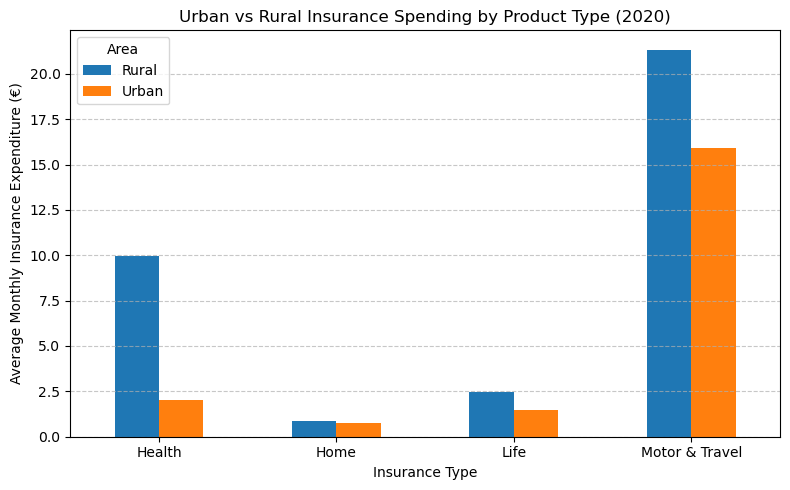

In [15]:
area_pivot.plot(kind="bar", figsize=(8,5))

plt.title("Urban vs Rural Insurance Spending by Product Type (2020)")
plt.xlabel("Insurance Type") 
plt.xticks(rotation=0)
plt.ylabel("Average Monthly Insurance Expenditure (€)")
plt.legend(title="Area")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

## Health Insurance Spending by Spending Class

In [16]:
spending_df = df[df["category_type"] == "spending_class"]
spending_df.head()

,year,category_type,segment,insurance_type,insurance_expenditure
128,2008,spending_class,Up to 750€,Life,0.07
129,2008,spending_class,751–1100€,Life,0.50
130,2008,spending_class,1101–1450€,Life,0.38
131,2008,spending_class,1451–1800€,Life,3.41
132,2008,spending_class,1801–2200€,Life,4.13


In [17]:
spending_grouped = spending_df.groupby(["year", "segment", "insurance_type"])["insurance_expenditure"].mean().reset_index()
spending_grouped

,year,segment,insurance_type,insurance_expenditure
0,2008,1101–1450€,Health,0.55
1,2008,1101–1450€,Home,0.17
2,2008,1101–1450€,Life,0.38
3,2008,1101–1450€,Motor & Travel,11.75
4,2008,1451–1800€,Health,1.57
...,...,...,...,...
91,2020,751–1100€,Motor & Travel,9.08
92,2020,Up to 750€,Health,0.00
93,2020,Up to 750€,Home,0.01
94,2020,Up to 750€,Life,0.00


In [18]:
spending_2020 = spending_grouped[spending_grouped["year"] == 2020]
spending_2020.head()
spending_2020

,year,segment,insurance_type,insurance_expenditure
64,2020,1101–1450€,Health,1.63
65,2020,1101–1450€,Home,0.26
66,2020,1101–1450€,Life,0.62
67,2020,1101–1450€,Motor & Travel,16.08
68,2020,1451–1800€,Health,1.39
69,2020,1451–1800€,Home,0.39
70,2020,1451–1800€,Life,1.74
71,2020,1451–1800€,Motor & Travel,22.32
72,2020,1801–2200€,Health,4.42
73,2020,1801–2200€,Home,0.94


In [19]:
health_2020 = spending_2020[spending_2020["insurance_type"] == "Health"]
health_2020.head()
health_2020

,year,segment,insurance_type,insurance_expenditure
64,2020,1101–1450€,Health,1.63
68,2020,1451–1800€,Health,1.39
72,2020,1801–2200€,Health,4.42
76,2020,2201–2800€,Health,13.90
80,2020,2801–3500€,Health,20.72
84,2020,3500€+,Health,75.40
88,2020,751–1100€,Health,0.44
92,2020,Up to 750€,Health,0.00


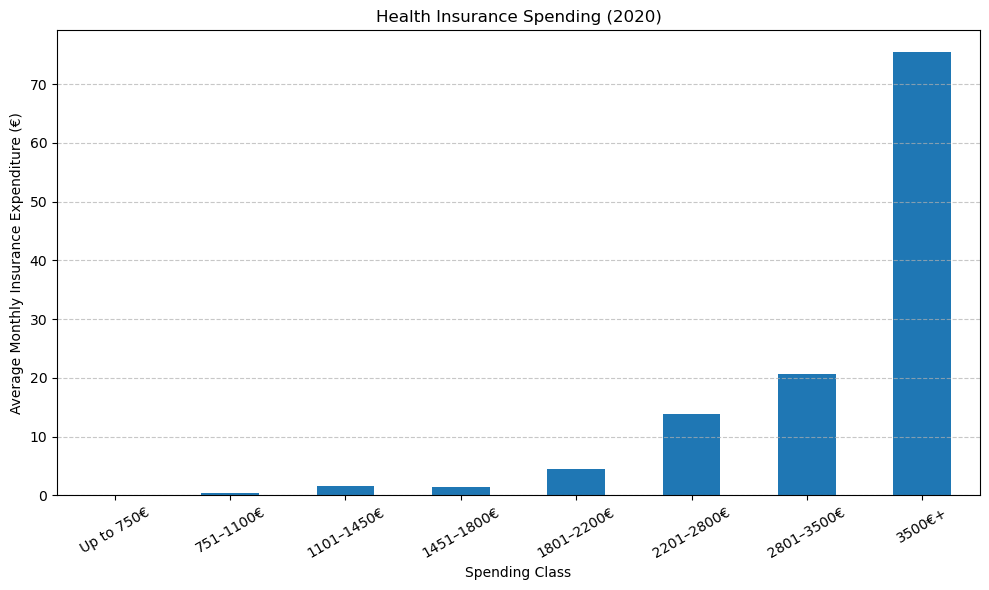

In [20]:
order = [
    "Up to 750€",
    "751–1100€",
    "1101–1450€",
    "1451–1800€",
    "1801–2200€",
    "2201–2800€",
    "2801–3500€",
    "3500€+"
]
health_2020 = spending_2020[spending_2020["insurance_type"] == "Health"].copy()
health_2020["segment"] = pd.Categorical(health_2020["segment"], categories=order, ordered=True)
health_2020 = health_2020.sort_values("segment")

health_2020.plot(x="segment", y="insurance_expenditure", kind="bar", figsize=(10,6), legend=False)

plt.title("Health Insurance Spending (2020)")
plt.xlabel("Spending Class")
plt.ylabel("Average Monthly Insurance Expenditure (€)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()